```markdown
# Dự án Nhận diện Thiết bị Bảo hộ Lao động (PPE) với YOLOv8
Notebook này thực hiện huấn luyện và đánh giá mô hình YOLOv8 để nhận diện 5 lớp đối tượng: Helmet, No-Helmet, Vest, No-Vest, và Person.
```

```markdown
## 1. Chuẩn bị Môi trường và Dữ liệu
Kết nối Google Drive, giải nén tập dữ liệu và cài đặt các thư viện cần thiết.
```

In [ ]:
# 1. Kết nối với Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Tạo thư mục đích và giải nén siêu tốc
import os
os.makedirs('/content/dataset', exist_ok=True)
!unzip -q "/content/drive/MyDrive/DataSet/PPE_dataset.zip" -d "/content/dataset/"

# 3. Cài đặt thư viện
!pip install ultralytics -q
import ultralytics
ultralytics.checks()

# 4. Thiết lập và tiến hành Huấn luyện (YOLOv8s với 5 class)
from ultralytics import YOLO
import shutil

# Khởi tạo mô hình cơ sở
model = YOLO('yolov8s.pt')

In [7]:
# 4. Thiết lập và tiến hành Huấn luyện (Tự động Resume nếu có thể)
import os
import shutil
from ultralytics import YOLO

# Đường dẫn lưu trữ
local_train_dir = '/content/runs/train/ppe_5classes_model'
drive_save_dir = '/content/drive/MyDrive/DataSet/ppe_5classes_model_results'

# Kiểm tra file weight để resume
last_weight_path = os.path.join(local_train_dir, 'weights/last.pt')
drive_weight_path = os.path.join(drive_save_dir, 'weights/last.pt')

if os.path.exists(last_weight_path):
    print("--- Tìm thấy file weight cục bộ. Đang tiếp tục huấn luyện... ---")
    model = YOLO(last_weight_path)
    resume_flag = True
elif os.path.exists(drive_weight_path):
    print("--- Tìm thấy file weight trên Drive. Đang sao chép về máy ảo để resume... ---")
    os.makedirs(os.path.dirname(last_weight_path), exist_ok=True)
    shutil.copy(drive_weight_path, last_weight_path)
    model = YOLO(last_weight_path)
    resume_flag = True
else:
    print("--- Không tìm thấy file resume. Bắt đầu huấn luyện mới từ đầu... ---")
    model = YOLO('yolov8s.pt')
    resume_flag = False

try:
    results = model.train(
        data='/content/dataset/PPE_dataset/data.yaml',
        epochs=100,
        imgsz=640,
        batch=16,
        device=0,
        project='/content/runs/train',
        name='ppe_5classes_model',
        resume=resume_flag
    )

    # 5. Tự động sao lưu kết quả vào Drive
    print("--- Đang sao lưu kết quả vào Google Drive... ---")
    if os.path.exists(drive_save_dir):
        # Nếu thư mục đã tồn tại, xóa đi để cập nhật bản mới nhất hoặc đổi tên
        backup_name = drive_save_dir + '_backup'
        if os.path.exists(backup_name): shutil.rmtree(backup_name)
        os.rename(drive_save_dir, backup_name)

    shutil.copytree(local_train_dir, drive_save_dir)
    print(f"Đã hoàn tất và lưu tại: {drive_save_dir}")

except Exception as e:
    print(f"Lỗi: {e}")

# Kiểm tra nhanh nội dung trên Drive
print("\nDanh sách file trên Drive:")
!ls -R "{drive_save_dir}" | head -n 20

--- Tìm thấy file weight cục bộ. Đang tiếp tục huấn luyện... ---
Ultralytics 8.4.94 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/PPE_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/runs/train/ppe_5classes_model/weights/last.pt, momentum=0.937,

```markdown
## 2. Huấn luyện Mô hình (Training)
Tiến hành huấn luyện mô hình YOLOv8s với khả năng tự động lưu và khôi phục (Resume) từ Google Drive.
```

In [9]:
from ultralytics import YOLO
import os

# Tải mô hình tốt nhất đã huấn luyện (best.pt)
model_path = '/content/runs/train/ppe_5classes_model/weights/best.pt'

if os.path.exists(model_path):
    model = YOLO(model_path)

    # Chạy đánh giá trên tập validation
    metrics = model.val(data='/content/dataset/PPE_dataset/data.yaml')

    print(f"mAP50-95: {metrics.box.map:.3f}")
    print(f"mAP50: {metrics.box.map50:.3f}")
    print(f"Precision: {metrics.box.mp:.3f}")
    print(f"Recall: {metrics.box.mr:.3f}")
else:
    print("Không tìm thấy file best.pt. Hãy đảm bảo quá trình huấn luyện đã tạo ra trọng số.")

Ultralytics 8.4.94 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,127,519 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1622.5±592.2 MB/s, size: 53.4 KB)
val: Scanning /content/dataset/PPE_dataset/valid/labels.cache... 406 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 406/406 113.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 26/26 2.7it/s 9.6s
                   all        406       3095      0.919      0.862      0.917      0.609
                helmet        246        531      0.939      0.871      0.916      0.587
             no_helmet        241        523      0.919      0.806      0.882      0.527
               no_vest        269        649      0.883      0.841      0.895      0.524
                person        406       1042      0.931        0.9      0.944      0.695
                  vest        215 

```markdown
## 3. Đánh giá và Trực quan hóa Kết quả (Evaluation & Visualization)
Phân tích độ chính xác của mô hình thông qua các chỉ số mAP và biểu đồ Confusion Matrix.
```

--- Confusion Matrix ---


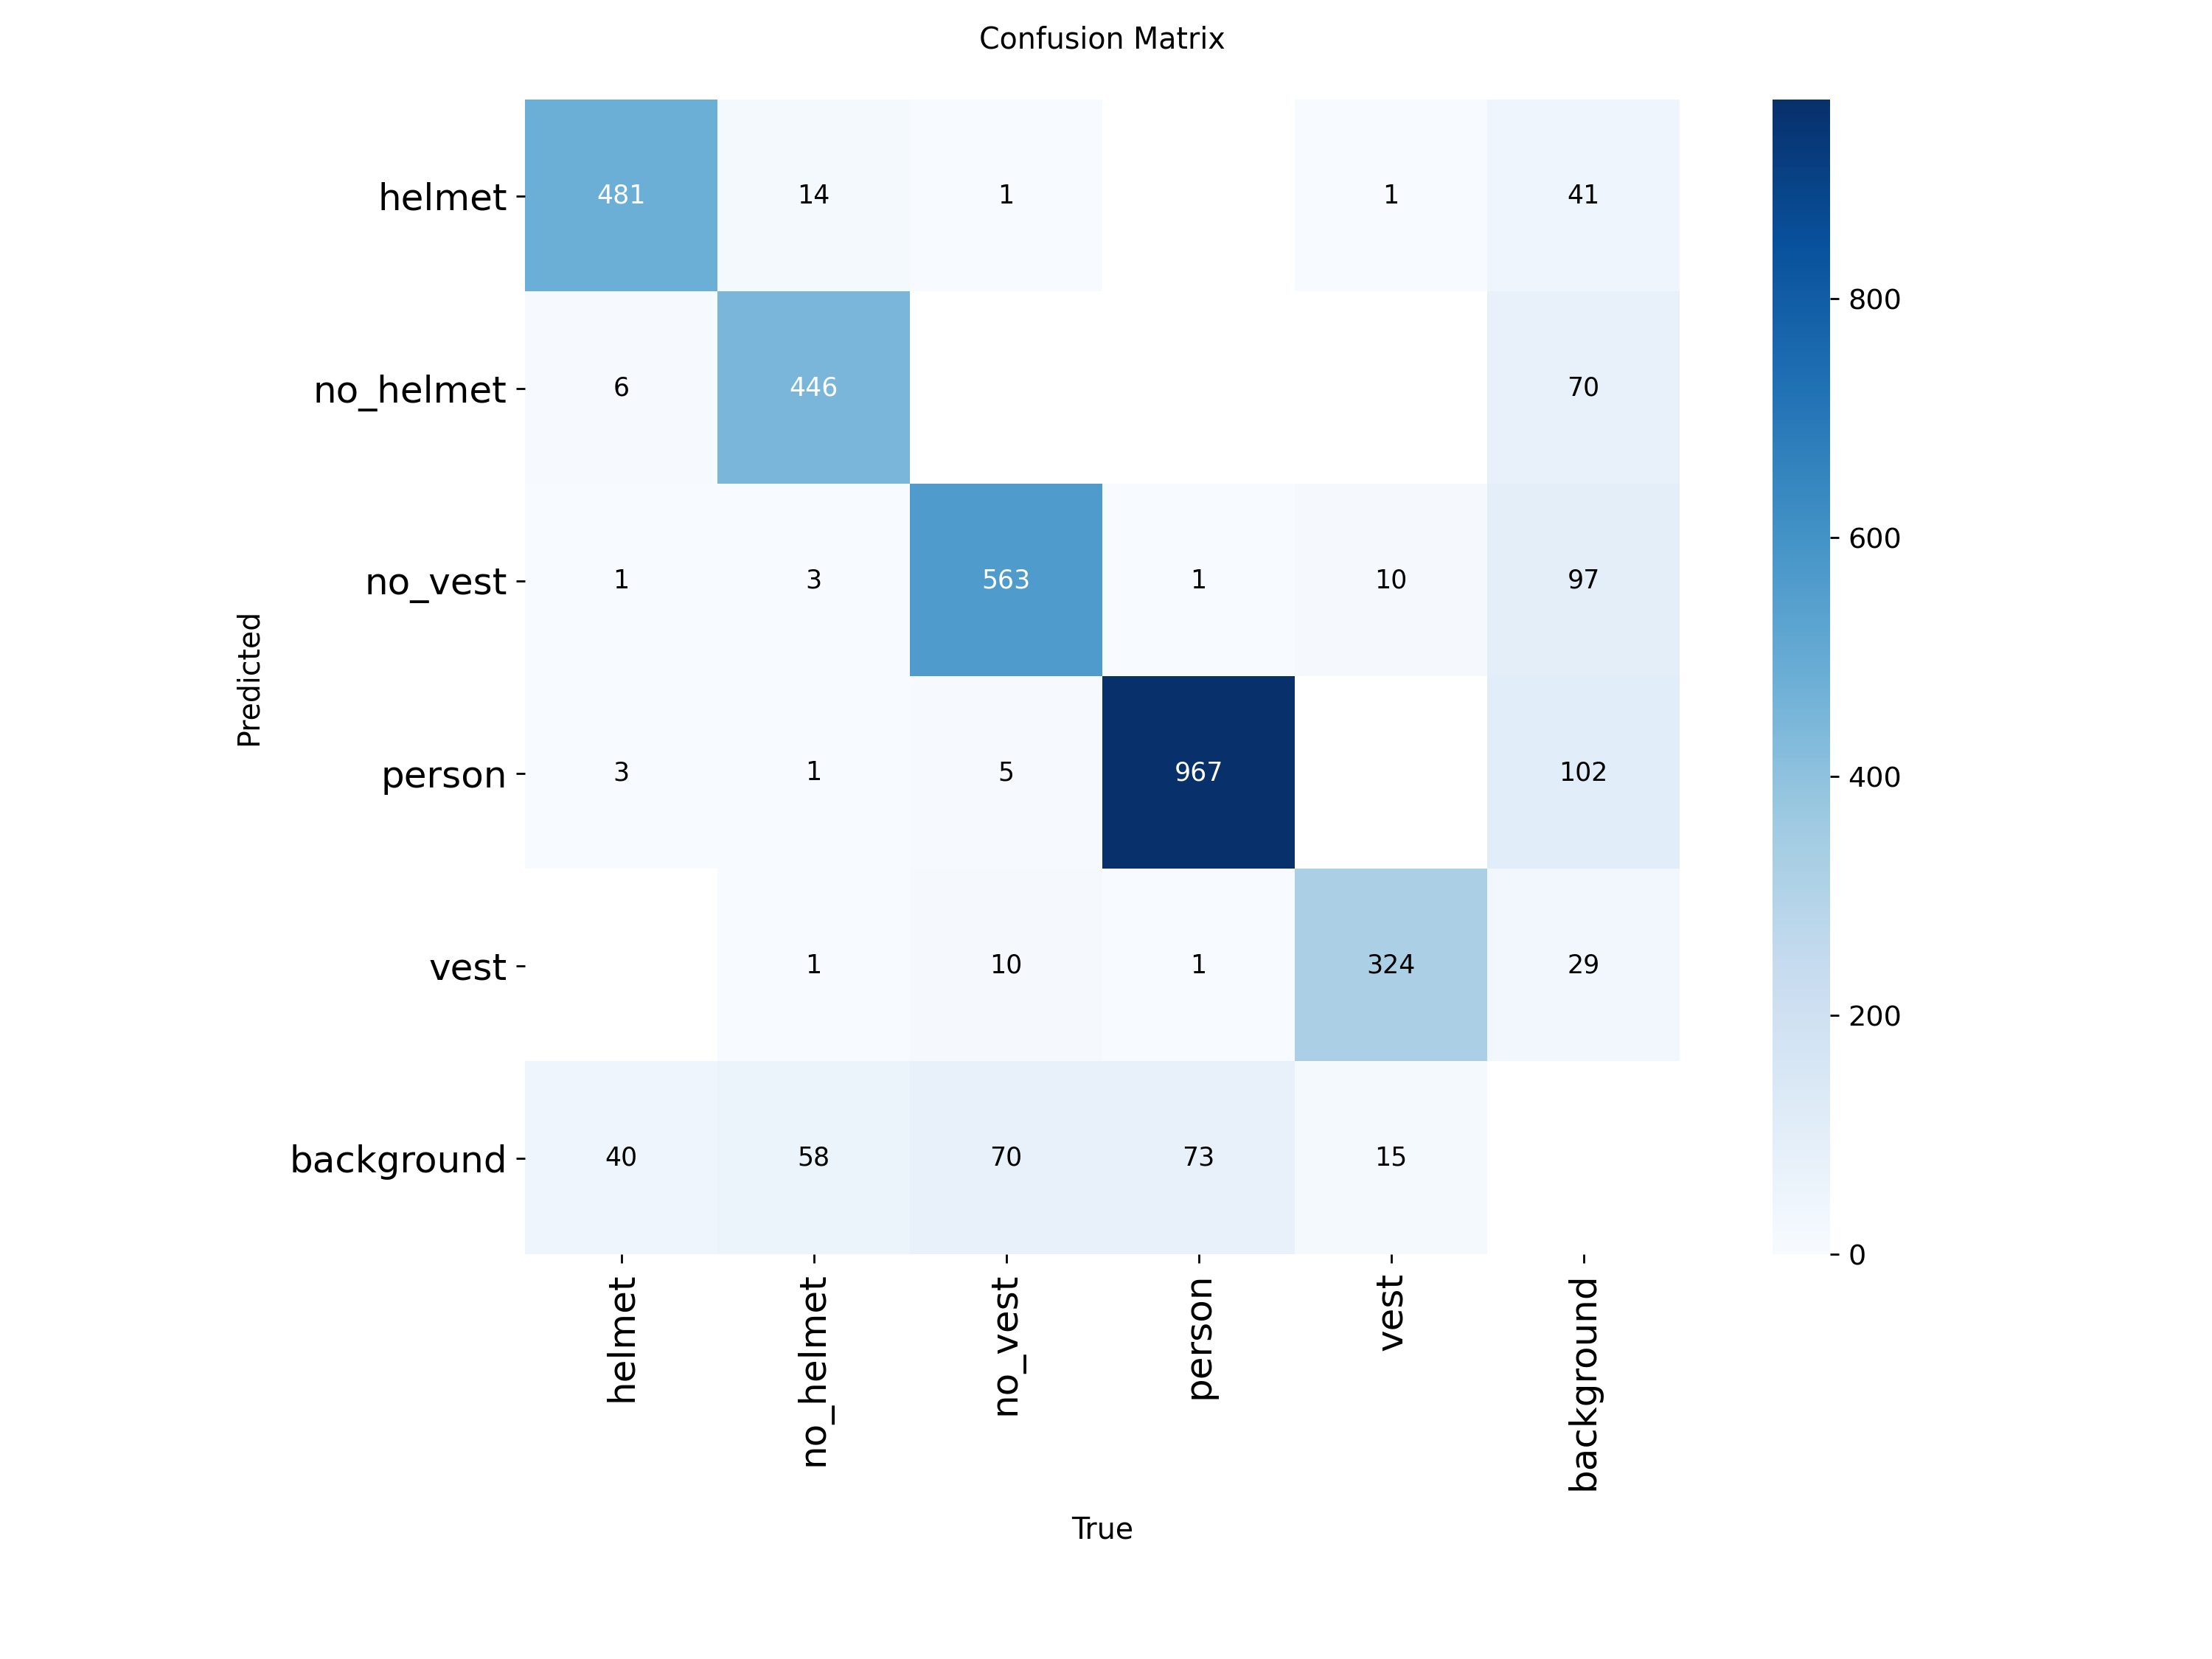

--- Training Results Charts ---


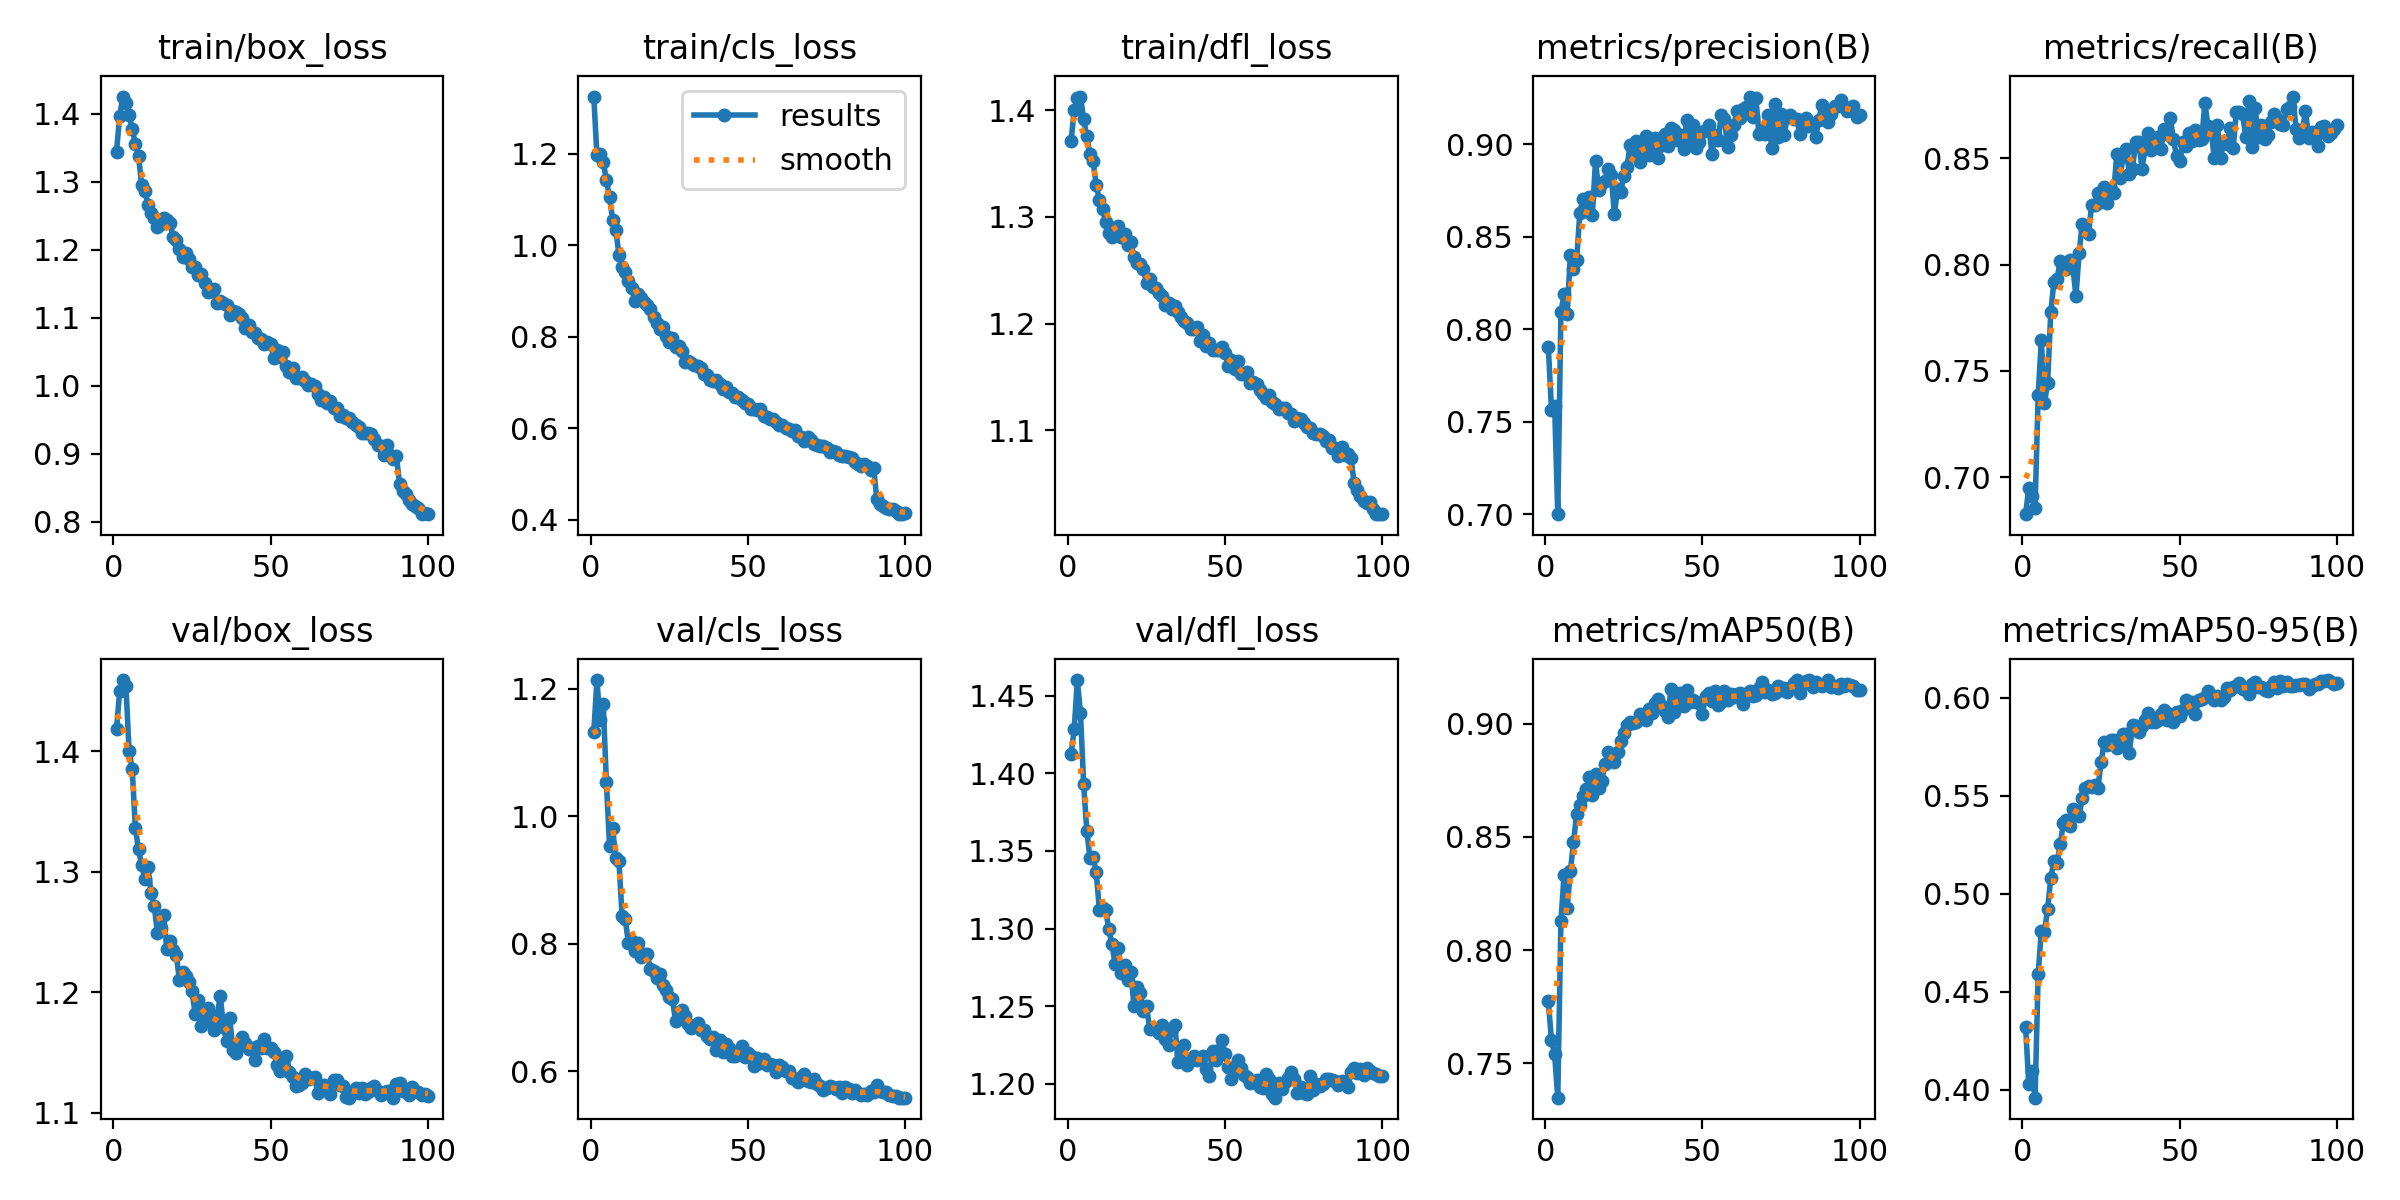

In [10]:
from IPython.display import Image, display

results_dir = '/content/runs/train/ppe_5classes_model'

# Hiển thị Ma trận nhầm lẫn (Confusion Matrix)
if os.path.exists(f"{results_dir}/confusion_matrix.png"):
    print("--- Confusion Matrix ---")
    display(Image(filename=f"{results_dir}/confusion_matrix.png", width=800))

# Hiển thị biểu đồ kết quả (Results)
if os.path.exists(f"{results_dir}/results.png"):
    print("--- Training Results Charts ---")
    display(Image(filename=f"{results_dir}/results.png", width=800))